# Protein Folding as an Energy Minimisation Problem

The idea here is: a protein folds into the shape that minimises its free energy. If we can write that energy as a function of the configuration, then finding the folded structure is just an optimisation problem, and it can be mapped onto Ising Hamiltonians, which is exactly what quantum annealers and algorithms like VQE are designed to solve.

I'm using the HP (hydrophobic-polar) lattice model, which is a massive simplification of real protein folding but captures the core idea: hydrophobic residues want to be near each other and away from water, and that preference defines an energy landscape.

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_aer import AerSimulator

# the HP model represents a protein as a sequence of two types of amino acids:
# H (hydrophobic) - wants to avoid water, prefers to be buried inside
# P (polar) - happy on the surface in contact with water
#
# a short test sequence - 1 = hydrophobic, 0 = polar
sequence = [1, 0, 1, 1, 0, 1, 0, 1]
N = len(sequence)
print(f"Sequence length: {N}")
print(f"Sequence: {''.join(['H' if s else 'P' for s in sequence])}")

Sequence length: 8
Sequence: HPHHPHPH


## Placing residues on a 2D lattice

Each residue sits on a node of a 2D square lattice. The chain has to be self-avoiding (no two residues on the same site) and connected (each residue is adjacent to the next one in the sequence). I'm encoding moves as directions: 0=up, 1=right, 2=down, 3=left. The first residue is fixed at the origin and the first move is fixed rightward to break symmetry.

In [14]:
MOVES = {
    0: (0, 1),   # up
    1: (1, 0),   # right
    2: (0, -1),  # down
    3: (-1, 0),  # left
}

def decode_fold(sequence, moves):
    """
    Given a sequence of direction choices, lay out the chain on the lattice.
    Returns list of (x,y) positions or None if the fold is invalid (self-intersecting).
    """
    positions = [(0, 0)]
    for m in moves:
        dx, dy = MOVES[m]
        new_pos = (positions[-1][0] + dx, positions[-1][1] + dy)
        if new_pos in positions:
            return None
        positions.append(new_pos)
    return positions

def compute_energy(sequence, positions):
    """
    Energy = negative count of non-bonded H-H contacts.
    Two H residues that are adjacent on the lattice but NOT adjacent in the chain
    contribute -1 to the energy. Lower energy = better fold.
    """
    energy = 0
    pos_set = {pos: i for i, pos in enumerate(positions)}
    for i, pos in enumerate(positions):
        if sequence[i] != 1:
            continue
        for dx, dy in MOVES.values():
            neighbour = (pos[0] + dx, pos[1] + dy)
            if neighbour in pos_set:
                j = pos_set[neighbour]
                if j > i + 1 and sequence[j] == 1:
                    energy -= 1
    return energy

# quick test: a straight line should have zero non-bonded contacts
straight = [1] * (N - 1)
positions = decode_fold(sequence, straight)
print(f"Straight fold energy: {compute_energy(sequence, positions)}")

Straight fold energy: 0


## Brute force: enumerate all valid folds

For short chains we can just try every possible fold. The number of possible move sequences is $4^{N-1}$ but most self-intersect. For N=8 this is manageable, for real proteins (hundreds of residues) it's completely intractable, which is why we need better methods.

In [15]:
valid_folds = []
energies = []

for moves in product(range(4), repeat=N-2):
    full_moves = [1] + list(moves)
    positions = decode_fold(sequence, full_moves)
    if positions is not None:
        e = compute_energy(sequence, positions)
        valid_folds.append(positions)
        energies.append(e)

energies = np.array(energies)
print(f"Total valid folds: {len(valid_folds)}")
print(f"Energy range: [{energies.min()}, {energies.max()}]")
print(f"Number of ground state folds: {np.sum(energies == energies.min())}")
print(f"Ground state energy: {energies.min()}")

Total valid folds: 543
Energy range: [-3, 0]
Number of ground state folds: 8
Ground state energy: -3


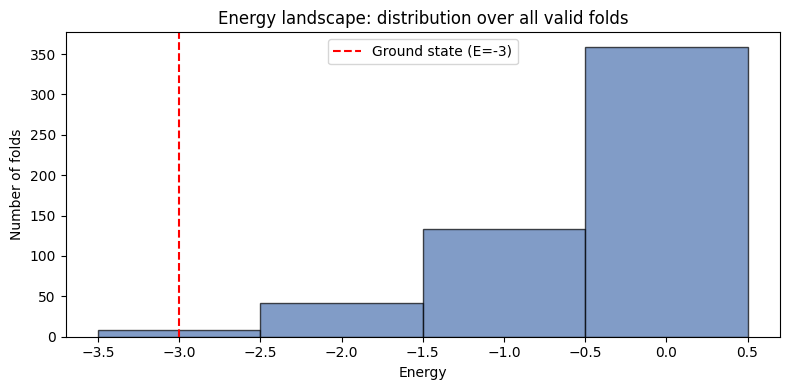

In [27]:
# distribution of energies across all valid folds
# this is the energy landscape - most folds are mediocre, very few are optimal

plt.figure(figsize=(8, 4))
plt.hist(energies, bins=range(int(energies.min()), int(energies.max()) + 2),
         edgecolor='black', alpha=0.7, align='left', color='#4C72B0')
plt.xlabel('Energy')
plt.ylabel('Number of folds')
plt.title('Energy landscape: distribution over all valid folds')
plt.axvline(x=energies.min(), color='red', linestyle='--', label=f'Ground state (E={energies.min():.0f})')
plt.legend()
plt.tight_layout()
plt.show()

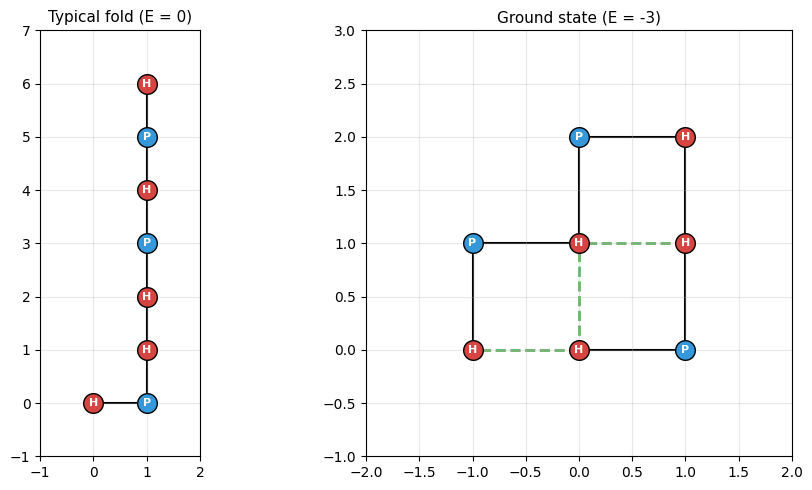

In [17]:
def plot_fold(sequence, positions, energy, ax=None):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    xs = [p[0] for p in positions]
    ys = [p[1] for p in positions]
    ax.plot(xs, ys, 'k-', linewidth=1.5, zorder=1)

    for i, (x, y) in enumerate(positions):
        color = '#D64541' if sequence[i] == 1 else '#3498DB'
        label = 'H' if sequence[i] == 1 else 'P'
        ax.scatter(x, y, c=color, s=200, zorder=2, edgecolors='black', linewidth=1)
        ax.annotate(label, (x, y), ha='center', va='center', fontsize=8,
                    fontweight='bold', color='white')

    # highlight non-bonded H-H contacts
    pos_set = {pos: i for i, pos in enumerate(positions)}
    for i, pos in enumerate(positions):
        if sequence[i] != 1:
            continue
        for dx, dy in MOVES.values():
            nb = (pos[0] + dx, pos[1] + dy)
            if nb in pos_set:
                j = pos_set[nb]
                if j > i + 1 and sequence[j] == 1:
                    ax.plot([pos[0], nb[0]], [pos[1], nb[1]], 'g--',
                            linewidth=2, alpha=0.6, zorder=0)

    ax.set_title(f'Energy = {energy}', fontsize=11)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(min(xs)-1, max(xs)+1)
    ax.set_ylim(min(ys)-1, max(ys)+1)

ground_idx = np.where(energies == energies.min())[0][0]
mid_idx = np.where(energies == 0)[0][0]

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_fold(sequence, valid_folds[mid_idx], 0, axes[0])
axes[0].set_title('Typical fold (E = 0)', fontsize=11)
plot_fold(sequence, valid_folds[ground_idx], energies.min(), axes[1])
axes[1].set_title(f'Ground state (E = {energies.min():.0f})', fontsize=11)
plt.tight_layout()
plt.show()

## Encoding the protein problem as a Hamiltonian

Now let's actually solve this with a quantum algorithm. I'll take a shorter 5-residue chain so the qubit count stays manageable, encode the energy function as a diagonal Hamiltonian using `SparsePauliOp`, and then use VQE to find the ground state.

The encoding: each move in the fold needs 2 qubits to represent 4 directions (00=up, 01=right, 10=down, 11=left). With the first move fixed, a 5-residue chain has 3 free moves = 6 qubits. The Hamiltonian is diagonal in the computational basis - each bitstring maps to a fold, and its eigenvalue is the HP contact energy (with a large penalty for invalid folds).

In [18]:
# smaller chain for the quantum solve, 5 residues keeps us at 6 qubits
seq_small = [1, 0, 1, 1, 0]  # HPHHP
N_small = len(seq_small)
n_free_moves = N_small - 2  # first move fixed
n_qubits_vqe = n_free_moves * 2  # 2 bits per move direction
print(f"Sequence: {''.join(['H' if s else 'P' for s in seq_small])}")
print(f"Free moves: {n_free_moves}, Qubits needed: {n_qubits_vqe}")

# build the energy for every 6-qubit computational basis state
# each basis state |b5 b4 b3 b2 b1 b0> encodes 3 moves:
#   move 0 = 2*b1 + b0, move 1 = 2*b3 + b2, move 2 = 2*b5 + b4

penalty = 10  # large penalty for invalid (self-intersecting) folds
dim_vqe = 2**n_qubits_vqe
energies_vqe = np.zeros(dim_vqe)

valid_count = 0
for idx in range(dim_vqe):
    bits = format(idx, f'0{n_qubits_vqe}b')[::-1]  # little-endian to match Qiskit
    moves_decoded = []
    for m in range(n_free_moves):
        move_val = int(bits[2*m]) + 2 * int(bits[2*m + 1])
        moves_decoded.append(move_val)
    
    full_moves = [1] + moves_decoded
    positions = decode_fold(seq_small, full_moves)
    
    if positions is None:
        energies_vqe[idx] = penalty
    else:
        energies_vqe[idx] = compute_energy(seq_small, positions)
        valid_count += 1

print(f"Valid folds: {valid_count} out of {dim_vqe} basis states")
print(f"Ground state energy: {energies_vqe[energies_vqe < penalty].min()}")
print(f"Ground state bitstrings: {np.sum(energies_vqe == energies_vqe[energies_vqe < penalty].min())}")

Sequence: HPHHP
Free moves: 3, Qubits needed: 6
Valid folds: 25 out of 64 basis states
Ground state energy: -1.0
Ground state bitstrings: 4


In [26]:
# building the diagonal Hamiltonian as a SparsePauliOp
from qiskit.quantum_info import Operator

H_protein = SparsePauliOp.from_operator(np.diag(energies_vqe)).simplify()
print(f"Hamiltonian has {len(H_protein)} Pauli terms")
print(f"Qubits: {H_protein.num_qubits}")

# sanity check: eigenvalues should match our energy array
H_matrix = H_protein.to_matrix()
eigvals_check = np.sort(np.real(np.diag(H_matrix)))
assert np.allclose(eigvals_check, np.sort(energies_vqe)), "Mismatch"
print("Hamiltonian eigenvalues match brute-force energies")

Hamiltonian has 64 Pauli terms
Qubits: 6
Hamiltonian eigenvalues match brute-force energies


## Solving with VQE

VQE uses a parameterised circuit (ansatz) and a classical optimiser to find the parameters that minimise $\langle \psi(\theta) | H | \psi(\theta) \rangle$. If the ansatz is expressive enough and the optimiser finds the global minimum, this gives the ground state - the optimal fold.

Ansatz parameters: 36


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20996\2255949556.py:4: DeprecationWarning: The class ``qiskit.circuit.library.n_local.efficient_su2.EfficientSU2`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.efficient_su2 instead.
  ansatz = EfficientSU2(n_qubits_vqe, reps=2, entanglement='linear')


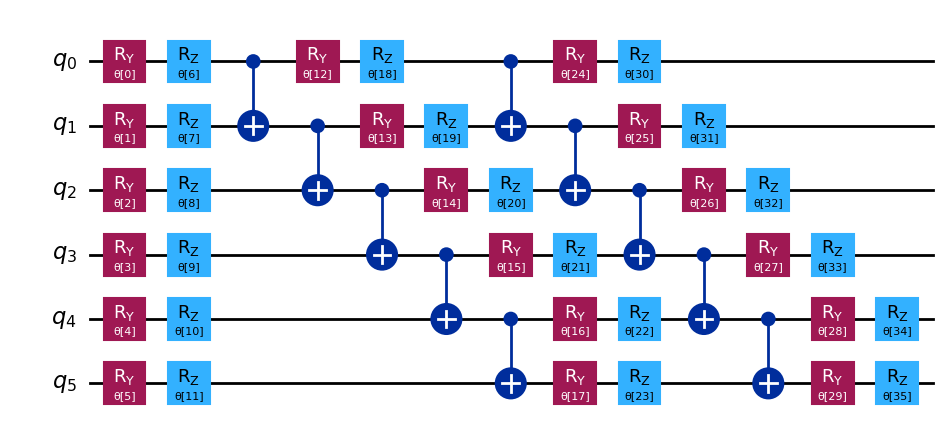

In [20]:
from qiskit.circuit.library import EfficientSU2

# EfficientSU2: layers of Ry, Rz rotations followed by entangling gates
ansatz = EfficientSU2(n_qubits_vqe, reps=2, entanglement='linear')
print(f"Ansatz parameters: {ansatz.num_parameters}")
ansatz.decompose().draw('mpl', fold=60)

In [21]:
# VQE optimisation loop using statevector simulation
from scipy.optimize import minimize

def vqe_cost(params, ansatz, hamiltonian):
    """Compute <psi(params)|H|psi(params)> exactly."""
    qc = ansatz.assign_parameters(params)
    sv = Statevector.from_instruction(qc)
    return np.real(sv.expectation_value(hamiltonian))

best_energy_vqe = np.inf
best_params_vqe = None
vqe_history = []

for trial in range(20):
    x0 = np.random.randn(ansatz.num_parameters) * np.pi
    
    trial_history = []
    def callback(params):
        e = vqe_cost(params, ansatz, H_protein)
        trial_history.append(e)
    
    res = minimize(vqe_cost, x0, args=(ansatz, H_protein),
                   method='COBYLA', callback=callback,
                   options={'maxiter': 500})
    
    vqe_history.extend(trial_history)
    if res.fun < best_energy_vqe:
        best_energy_vqe = res.fun
        best_params_vqe = res.x
        print(f"  Trial {trial}: new best energy = {best_energy_vqe:.4f}")

true_ground = energies_vqe[energies_vqe < penalty].min()
print(f"\nVQE ground state energy: {best_energy_vqe:.4f}")
print(f"True ground state energy: {true_ground:.1f}")
print(f"Match: {np.abs(best_energy_vqe - true_ground) < 0.1}")

  Trial 0: new best energy = 0.0012
  Trial 1: new best energy = 0.0007
  Trial 3: new best energy = 0.0005
  Trial 4: new best energy = -0.9705
  Trial 5: new best energy = -0.9946

VQE ground state energy: -0.9946
True ground state energy: -1.0
Match: True


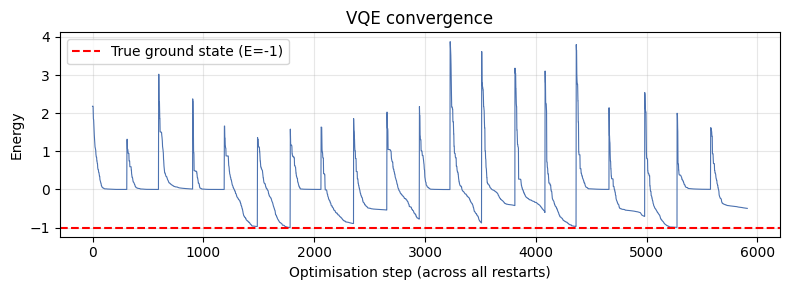

In [22]:
plt.figure(figsize=(8, 3))
plt.plot(vqe_history, color='#4C72B0', linewidth=0.8)
plt.axhline(y=true_ground, color='red', linestyle='--', label=f'True ground state (E={true_ground:.0f})')
plt.xlabel('Optimisation step (across all restarts)')
plt.ylabel('Energy')
plt.title('VQE convergence')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# extract the solution: measure the VQE output state
qc_final = ansatz.assign_parameters(best_params_vqe)
sv_final = Statevector.from_instruction(qc_final)
probs = sv_final.probabilities()

top_idx = np.argsort(probs)[::-1][:5]
print("Top 5 most probable states from VQE:")
for idx in top_idx:
    bits = format(idx, f'0{n_qubits_vqe}b')[::-1]
    e = energies_vqe[idx]
    tag = "← GROUND STATE" if np.abs(e - true_ground) < 0.01 else ("(invalid)" if e >= penalty else "")
    print(f"  |{format(idx, f'0{n_qubits_vqe}b')}> prob={probs[idx]:.4f}  energy={e:.1f}  {tag}")

Top 5 most probable states from VQE:
  |111110> prob=0.7842  energy=-1.0  ← GROUND STATE
  |101110> prob=0.2132  energy=-1.0  ← GROUND STATE
  |000110> prob=0.0015  energy=0.0  
  |100110> prob=0.0005  energy=0.0  
  |001110> prob=0.0001  energy=10.0  (invalid)


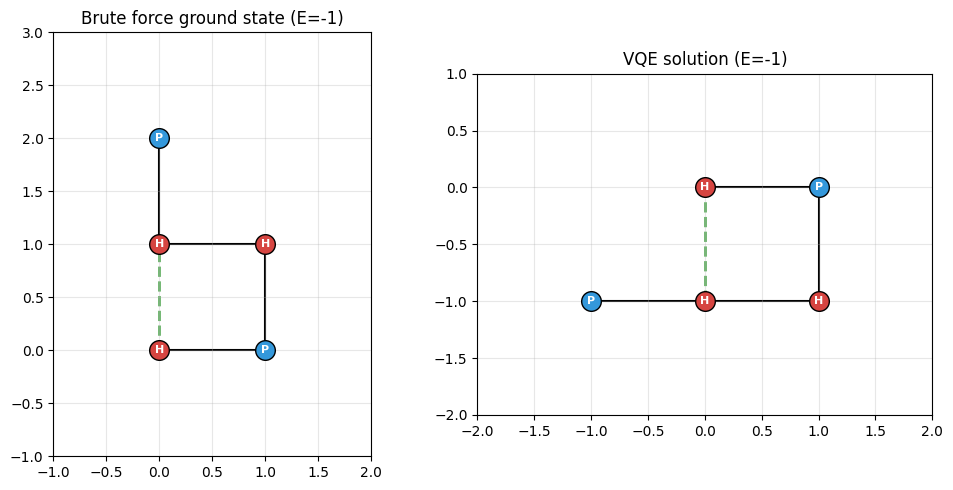

In [24]:
# decode the VQE solution and compare against brute force
best_vqe_idx = np.argmax(probs)
bits_vqe = format(best_vqe_idx, f'0{n_qubits_vqe}b')[::-1]
moves_vqe = []
for m in range(n_free_moves):
    move_val = int(bits_vqe[2*m]) + 2 * int(bits_vqe[2*m + 1])
    moves_vqe.append(move_val)

full_moves_vqe = [1] + moves_vqe
positions_vqe = decode_fold(seq_small, full_moves_vqe)

# brute force best for the small chain
bf_energies = []
bf_folds = []
for moves in product(range(4), repeat=N_small - 2):
    full = [1] + list(moves)
    pos = decode_fold(seq_small, full)
    if pos is not None:
        e = compute_energy(seq_small, pos)
        bf_energies.append(e)
        bf_folds.append(pos)
bf_energies = np.array(bf_energies)
bf_best_idx = np.argmin(bf_energies)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
plot_fold(seq_small, bf_folds[bf_best_idx], bf_energies[bf_best_idx], axes[0])
axes[0].set_title(f'Brute force ground state (E={bf_energies[bf_best_idx]:.0f})')

if positions_vqe is not None:
    plot_fold(seq_small, positions_vqe, compute_energy(seq_small, positions_vqe), axes[1])
    axes[1].set_title(f'VQE solution (E={compute_energy(seq_small, positions_vqe):.0f})')
else:
    axes[1].text(0.5, 0.5, 'VQE found invalid fold', ha='center', va='center', fontsize=12)
    axes[1].set_title('VQE solution (invalid)')

plt.tight_layout()
plt.show()

## Why quantum? The scaling argument

The exponential growth of the configuration space is what makes this a quantum computing problem.

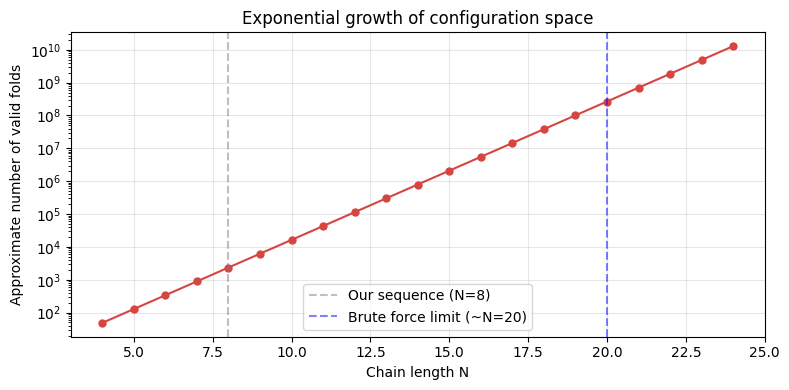

In [25]:
chain_lengths = np.arange(4, 25)
approx_configs = 2.638 ** chain_lengths  # connective constant for square lattice

plt.figure(figsize=(8, 4))
plt.semilogy(chain_lengths, approx_configs, 'o-', color='#D64541', markersize=5)
plt.xlabel('Chain length N')
plt.ylabel('Approximate number of valid folds')
plt.title('Exponential growth of configuration space')
plt.grid(True, alpha=0.3)
plt.axvline(x=N, color='gray', linestyle='--', alpha=0.5, label=f'Our sequence (N={N})')
plt.axvline(x=20, color='blue', linestyle='--', alpha=0.5, label='Brute force limit (~N=20)')
plt.legend()
plt.tight_layout()
plt.show()

# at N=50 we're looking at ~10^21 configurations
# quantum annealing exploits tunnelling to navigate this landscape
# VQE/QAOA use parameterised circuits to variationally approach the ground state